In [1]:
import xarray as xr
import pandas as pd
import sklearn
import seaborn as sns
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
data = pd.read_csv('https://www.spc.noaa.gov/wcm/data/1950-2021_actual_tornadoes.csv', sep=',',skiprows=0,
    skipfooter=0, engine='python')

data

,om,yr,mo,dy,date,time,tz,st,stf,stn,...,len,wid,ns,sn,sg,f1,f2,f3,f4,fc
0,192,1950,10,1,1950-10-01,21:00:00,3,OK,40,23,...,15.80,10,1,1,1,25,0,0,0,0
1,193,1950,10,9,1950-10-09,02:15:00,3,NC,37,9,...,2.00,880,1,1,1,47,0,0,0,0
2,195,1950,11,20,1950-11-20,02:20:00,3,KY,21,1,...,0.10,10,1,1,1,177,0,0,0,0
3,196,1950,11,20,1950-11-20,04:00:00,3,KY,21,2,...,0.10,10,1,1,1,209,0,0,0,0
4,197,1950,11,20,1950-11-20,07:30:00,3,MS,28,14,...,2.00,37,1,1,1,101,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67553,620523,2021,9,8,2021-09-08,15:32:00,3,PA,42,0,...,0.73,30,1,1,1,109,0,0,0,0
67554,620524,2021,9,8,2021-09-08,15:35:00,3,PA,42,0,...,1.45,30,1,1,1,109,0,0,0,0
67555,620525,2021,9,8,2021-09-08,19:08:00,3,FL,12,0,...,1.45,50,1,1,1,129,0,0,0,0
67556,620526,2021,9,9,2021-09-09,02:10:00,3,CT,9,0,...,0.75,75,1,1,1,13,0,0,0,0


In [5]:
# Isolate Illinois
data_ill = data.loc[data['st'] == 'IL']
data_ill.index = data_ill['date']
data_ill.index = pd.to_datetime(data_ill.index)
data_ill

,om,yr,mo,dy,date,time,tz,st,stf,stn,...,len,wid,ns,sn,sg,f1,f2,f3,f4,fc
date,,,,,,,,,,,,,,,,,,,,,
1950-12-02,198,1950,12,2,1950-12-02,15:00:00,3,IL,17,7,...,18.80,50,1,1,1,119,117,0,0,0
1950-12-02,199,1950,12,2,1950-12-02,16:00:00,3,IL,17,8,...,18.00,200,1,1,1,119,5,0,0,0
1950-12-02,201,1950,12,2,1950-12-02,17:30:00,3,IL,17,9,...,9.60,50,1,1,1,157,0,0,0,0
1950-01-25,6,1950,1,25,1950-01-25,21:00:00,3,IL,17,3,...,0.10,100,1,1,1,91,0,0,0,0
1950-01-03,2,1950,1,3,1950-01-03,11:55:00,3,IL,17,2,...,3.60,130,1,1,1,135,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-08-09,620382,2021,8,9,2021-08-09,17:26:00,3,IL,17,0,...,0.20,20,1,1,1,37,0,0,0,0
2021-08-09,620383,2021,8,9,2021-08-09,17:28:00,3,IL,17,0,...,3.90,400,1,1,1,89,0,0,0,0
2021-08-09,620384,2021,8,9,2021-08-09,17:38:00,3,IL,17,0,...,0.10,10,1,1,1,89,0,0,0,0


In [6]:
# Resample df1
data_ill_sum = data_ill.copy()
data_ill_sum = data_ill_sum.resample('ME').sum()
data_ill_sum

,om,yr,mo,dy,date,time,tz,st,stf,stn,...,len,wid,ns,sn,sg,f1,f2,f3,f4,fc
date,,,,,,,,,,,,,,,,,,,,,
1950-01-31,8,3900,2,28,1950-01-031950-01-25,11:55:0021:00:00,6,ILIL,34,5,...,3.70,230,2,2,2,226,0,0,0,0
1950-02-28,0,0,0,0,0,0,0,0,0,0,...,0.00,0,0,0,0,0,0,0,0,0
1950-03-31,48,1950,3,27,1950-03-27,16:30:00,3,IL,17,4,...,3.00,50,1,1,1,113,0,0,0,0
1950-04-30,0,0,0,0,0,0,0,0,0,0,...,0.00,0,0,0,0,0,0,0,0,0
1950-05-31,0,0,0,0,0,0,0,0,0,0,...,0.00,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-08-31,9926260,32336,128,177,2021-08-092021-08-092021-08-092021-08-092021-0...,15:35:0015:44:0015:45:0016:24:0016:28:0017:03:...,48,ILILILILILILILILILILILILILILILIL,272,0,...,24.74,1665,16,16,16,1100,37,0,0,0
2021-09-30,0,0,0,0,0,0,0,0,0,0,...,0.00,0,0,0,0,0,0,0,0,0
2021-10-31,6205800,20210,100,115,2021-10-032021-10-112021-10-112021-10-112021-1...,14:26:0013:37:0014:26:0015:28:0015:45:0016:10:...,30,ILILILILILILILILILIL,170,0,...,16.57,610,11,9,10,1325,0,0,0,0


In [10]:
# Resample df2
data_ill_avg = data_ill.copy()
data_ill_avg = data_ill_avg[['mo']]
data_ill_avg = data_ill_avg.resample('ME').mean()
data_ill_avg

,mo
date,
1950-01-31,1.0
1950-02-28,NaN
1950-03-31,3.0
1950-04-30,NaN
1950-05-31,NaN
...,...
2021-08-31,8.0
2021-09-30,NaN
2021-10-31,10.0


In [11]:
# Isolate column to use for analysis
data_ill_sum = data_ill_sum[['sg']]
data_ill_sum

,sg
date,
1950-01-31,2
1950-02-28,0
1950-03-31,1
1950-04-30,0
1950-05-31,0
...,...
2021-08-31,16
2021-09-30,0
2021-10-31,10


In [12]:
# Merge df1 and df2
df_ill = pd.merge(data_ill_sum, data_ill_avg, left_index = True, right_index = True)
df_ill

,sg,mo
date,,
1950-01-31,2,1.0
1950-02-28,0,NaN
1950-03-31,1,3.0
1950-04-30,0,NaN
1950-05-31,0,NaN
...,...,...
2021-08-31,16,8.0
2021-09-30,0,NaN
2021-10-31,10,10.0


In [13]:
# Set index to first day of the month
df_ill.index = df_ill.index.map(lambda d: d.replace(day=1))
df_ill = df_ill.dropna()
df_ill

,sg,mo
date,,
1950-01-01,2,1.0
1950-03-01,1,3.0
1950-06-01,1,6.0
1950-07-01,1,7.0
1950-12-01,3,12.0
...,...,...
2021-06-01,15,6.0
2021-07-01,8,7.0
2021-08-01,16,8.0


In [14]:
# Include dataset from M4N1
import datetime

enso = pd.read_csv('https://www.atmos.illinois.edu/~snesbitt/soi.dat',sep=r'\s+',header=None,skiprows=4,
    skipfooter=0, engine='python')
pdo = pd.read_csv('https://www.ncei.noaa.gov/pub/data/cmb/ersst/v5/index/ersst.v5.pdo.dat',sep=r'\s+',
    header=None,skiprows=2, engine='python')
nao = pd.read_csv('https://www.cpc.ncep.noaa.gov/products/precip/CWlink/pna/norm.nao.monthly.b5001.current.ascii.table',
    sep=r'\s+', header=None,skiprows=1, engine='python')
ao = pd.read_csv('https://www.cpc.ncep.noaa.gov/products/precip/CWlink/daily_ao_index/monthly.ao.index.b50.current.ascii.table',
    sep=r'\s+',header=None,skiprows=1, engine='python')

# Create DataFrames
enso_new=pd.DataFrame()
nao_new=pd.DataFrame()
pdo_new=pd.DataFrame()
ao_new=pd.DataFrame()

enso_new['Date'] = pd.date_range(start=datetime.datetime(enso[0].iloc[0],1,1),end=datetime.datetime(enso[0].iloc[-1],12,1),freq="MS")
nao_new['Date'] = pd.date_range(start=datetime.datetime(nao[0].iloc[0],1,1),end=datetime.datetime(nao[0].iloc[-1],12,1),freq="MS")
pdo_new['Date'] = pd.date_range(start=datetime.datetime(pdo[0].iloc[0],1,1),end=datetime.datetime(pdo[0].iloc[-1],12,1),freq="MS")
ao_new['Date'] = pd.date_range(start=datetime.datetime(ao[0].iloc[0],1,1),end=datetime.datetime(ao[0].iloc[-1],12,1),freq="MS")

enso_new = enso_new.set_index('Date')
nao_new = nao_new.set_index('Date')
pdo_new = pdo_new.set_index('Date')
ao_new = ao_new.set_index('Date')

enso_new['ENSO']=enso.loc[:,1:].stack(dropna=False).values
nao_new['NAO']=nao.loc[:,1:].stack(dropna=False).values
pdo_new['PDO']=pdo.loc[:,1:].stack(dropna=False).values
ao_new['AO']=ao.loc[:,1:].stack(dropna=False).values


/tmp/ipykernel_12290/717494539.py:29: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  enso_new['ENSO']=enso.loc[:,1:].stack(dropna=False).values
/tmp/ipykernel_12290/717494539.py:30: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  nao_new['NAO']=nao.loc[:,1:].stack(dropna=False).values
/tmp/ipykernel_12290/717494539.py:31: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.

In [15]:
# Merge DataFrames
newdf_all = pd.merge(enso_new,pdo_new, left_index=True, right_index=True)
newdf_all = pd.merge(newdf_all,nao_new, left_index=True, right_index=True)
newdf_all = pd.merge(newdf_all,ao_new, left_index=True, right_index=True)

newdf_all

,ENSO,PDO,NAO,AO
Date,,,,
1951-01-01,1.5,-1.19,0.08,-0.085
1951-02-01,0.9,-1.52,0.70,-0.400
1951-03-01,-0.1,-1.72,-1.02,-1.934
1951-04-01,-0.3,-1.35,-0.22,-0.776
1951-05-01,-0.7,-1.29,-0.59,-0.863
...,...,...,...,...
2025-08-01,0.4,-3.20,0.26,0.036
2025-09-01,0.0,-2.33,-0.80,0.048
2025-10-01,-99.9,-2.40,-0.96,0.064


In [16]:
# Merge Illinois data with ENSO, MJO, AO, NAO
ill_enso = pd.merge(df_ill, newdf_all, left_index = True, right_index = True)
ill_enso

,sg,mo,ENSO,PDO,NAO,AO
1951-06-01,2,6.0,0.2,-1.77,-1.64,-0.918
1951-11-01,2,11.0,-0.8,-0.31,-0.39,-0.069
1951-12-01,1,12.0,-0.7,-1.45,1.32,1.987
1952-03-01,2,3.0,0.5,-1.67,-1.49,-1.859
1952-05-01,1,5.0,0.8,-2.07,-1.12,-0.774
...,...,...,...,...,...,...
2021-06-01,15,6.0,0.4,-1.82,0.77,0.845
2021-07-01,8,7.0,1.4,-2.00,0.03,0.630
2021-08-01,16,8.0,0.6,-0.95,-0.28,-0.209
2021-10-01,10,10.0,0.7,-3.13,-2.29,-0.146


In [19]:
# Random forest using ENSO, MJO, NAO, and AO to predict monthly tornadoes
X = ill_enso.drop(['mo','sg'], axis = 1)
y = ill_enso['sg']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

# create model
model_randForest = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=1)

# fit model
model_randForest.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Mean Squared Error: 63.857
R^2 = -0.38882466852262754


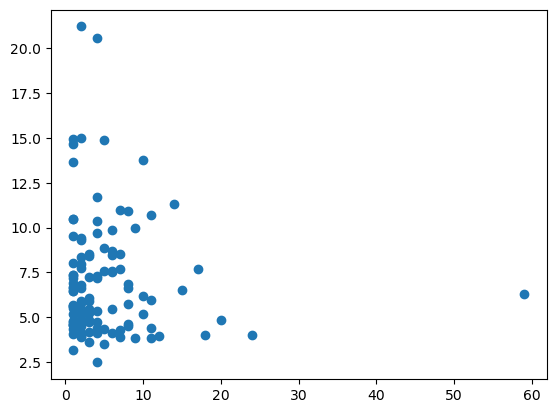

In [20]:
#  Create a scatter plot of the predicted and observed number of tornadoes over these states.
yhat = model_randForest.predict(X_test)
plt.scatter(y_test, yhat)

# Report the correlation coefficient and RMSE of your model.

mse_forest = mean_squared_error(y_test, yhat)
print('Mean Squared Error: %.3f' % mse_forest)

Rsqrd = r2_score(y_test, yhat)
print(f"R^2 = {Rsqrd}" )

In [22]:
# Create one hot encoder for month
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)
encoded_array = encoder.fit_transform(ill_enso[['mo']])

# Get feature names for the encoded columns
encoded_columns = encoder.get_feature_names_out(ill_enso[['mo']].columns)

# Convert encoded array back to DataFrame
encoded_df = pd.DataFrame(encoded_array, columns = encoded_columns)
encoded_df

,mo_1.0,mo_2.0,mo_3.0,mo_4.0,mo_5.0,mo_6.0,mo_7.0,mo_8.0,mo_9.0,mo_10.0,mo_11.0,mo_12.0
0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
435,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
436,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
437,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
438,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [23]:
encoded_df.index = ill_enso.index
df_monthly = pd.merge(ill_enso, encoded_df, left_index = True, right_index = True)
df_monthly

,sg,mo,ENSO,PDO,NAO,AO,mo_1.0,mo_2.0,mo_3.0,mo_4.0,mo_5.0,mo_6.0,mo_7.0,mo_8.0,mo_9.0,mo_10.0,mo_11.0,mo_12.0
1951-06-01,2,6.0,0.2,-1.77,-1.64,-0.918,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1951-11-01,2,11.0,-0.8,-0.31,-0.39,-0.069,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1951-12-01,1,12.0,-0.7,-1.45,1.32,1.987,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1952-03-01,2,3.0,0.5,-1.67,-1.49,-1.859,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1952-05-01,1,5.0,0.8,-2.07,-1.12,-0.774,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-06-01,15,6.0,0.4,-1.82,0.77,0.845,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2021-07-01,8,7.0,1.4,-2.00,0.03,0.630,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2021-08-01,16,8.0,0.6,-0.95,-0.28,-0.209,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2021-10-01,10,10.0,0.7,-3.13,-2.29,-0.146,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [24]:
# Repeat code for RandomForest with one hot encoder
# Random forest using ENSO, MJO, NAO, and AO to predict monthly tornadoes
X2 = df_monthly.drop('sg', axis=1)
y2 = df_monthly['sg']

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.25, random_state=0)

# create model
model_randForest = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=1)

# fit model
model_randForest.fit(X2_train, y2_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Mean Squared Error: 53.032
R^2 = -0.15339717216046367


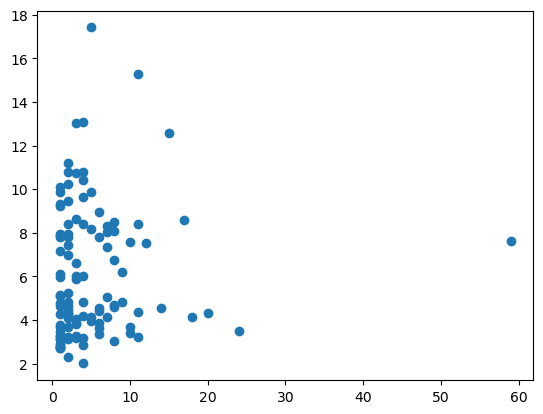

In [26]:
yhat2 = model_randForest.predict(X2_test)
plt.scatter(y2_test, yhat2)

# Report the correlation coefficient and RMSE of your model.

mse_forest = mean_squared_error(y2_test, yhat2)
print('Mean Squared Error: %.3f' % mse_forest)

Rsqrd = r2_score(y2_test, yhat2)
print(f"R^2 = {Rsqrd}" )

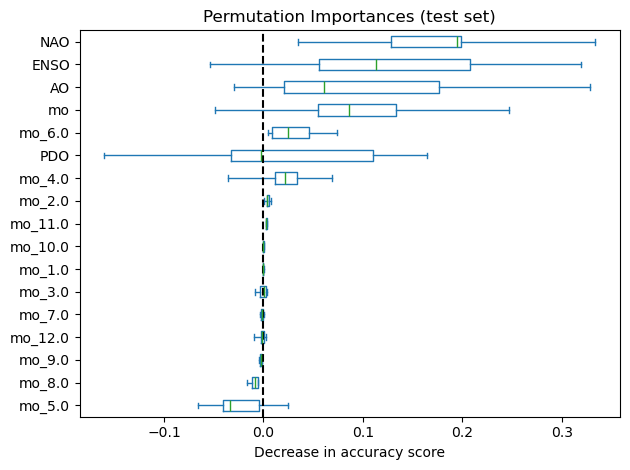

In [28]:
# Perform a feature importance and multipass permutation analysis of your features.
from sklearn.inspection import permutation_importance

result = permutation_importance(
    model_randForest, X2_test, y2_test, n_repeats=10, random_state=42, n_jobs=2
)

sorted_importances_idx = result.importances_mean.argsort()
importances = pd.DataFrame(
    result.importances[sorted_importances_idx].T,
    columns=X2.columns[sorted_importances_idx],
)
ax = importances.plot.box(vert=False, whis=10)
ax.set_title("Permutation Importances (test set)")
ax.axvline(x=0, color="k", linestyle="--")
ax.set_xlabel("Decrease in accuracy score")
ax.figure.tight_layout()

In [29]:
# Create a SHAP Summary Plot showing feature importance and feature effects.
# From SHAP tutorial
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import RocCurveDisplay, classification_report

clf = HistGradientBoostingClassifier(max_depth=6, learning_rate=0.07, max_leaf_nodes=31, random_state=0)
clf.fit(X2_train, y2_train)

,loss,'log_loss'
,learning_rate,0.07
,max_iter,100
,max_leaf_nodes,31
,max_depth,6
,min_samples_leaf,20
,l2_regularization,0.0
,max_features,1.0
,max_bins,255
,categorical_features,'from_dtype'
,monotonic_cst,None


In [30]:
!mamba install -c conda-forge -y "shap>=0.46" xgboost matplotlib ipywidgets plotly scikit-learn pandas numpy


Looking for: ["shap[version='>=0.46']", 'xgboost', 'matplotlib', 'ipywidgets', 'plotly', 'scikit-learn', 'pandas', 'numpy']

[+] 0.0s
[+] 0.1s
conda-forge/linux-64 ━━━━━━━━╸━━━━━━━━━━━━━━   0.0 B /  ??.?MB @  ??.?MB/s  0.1s
conda-forge/noarch   ━━━━━━━━╸━━━━━━━━━━━━━━   0.0 B /  ??.?MB @  ??.?MB/s  0.1s[+] 0.2s
conda-forge/linux-64 ━━━━━━━━━━╸━━━━━━━━━━━━   0.0 B /  ??.?MB @  ??.?MB/s  0.2s
conda-forge/noarch   ━━╸━━━━━━━━━━━━━━━━━━━━   3.9MB /  23.4MB @  25.2MB/s  0.2s[+] 0.3s
conda-forge/linux-64 ╸━━━━━━━━━━━━━━━━━━━━━━   3.5MB /  48.8MB @  13.6MB/s  0.3s
conda-forge/noarch   ━━━━━━━━━━╸━━━━━━━━━━━━  11.6MB /  23.4MB @  42.4MB/s  0.3s[+] 0.4s
conda-forge/linux-64 ━━━╸━━━━━━━━━━━━━━━━━━━   9.3MB /  48.8MB @  24.2MB/s  0.4s
conda-forge/noarch   ━━━━━━━━━━━━━╸━━━━━━━━━  14.8MB /  23.4MB @  44.3MB/s  0.4s[+] 0.5s
conda-forge/linux-64 ━━━━╸━━━━━━━━━━━━━━━━━━  12.4MB /  48.8MB @  27.5MB/s  0.5s
conda-forge/noarch   ━━━━━━━━━━━━━━━━━━━╸━━━  21.3MB /  23.4MB @  45.6MB/s  0.5s[+] 0.6s
conda-

In [32]:
import shap
explainer = shap.Explainer(clf.predict, X2_test)
shap_values = explainer(X2_test)
shap.initjs()

PermutationExplainer explainer: 111it [04:12,  2.32s/it]                         


/tmp/ipykernel_12290/4203601806.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X2_test)


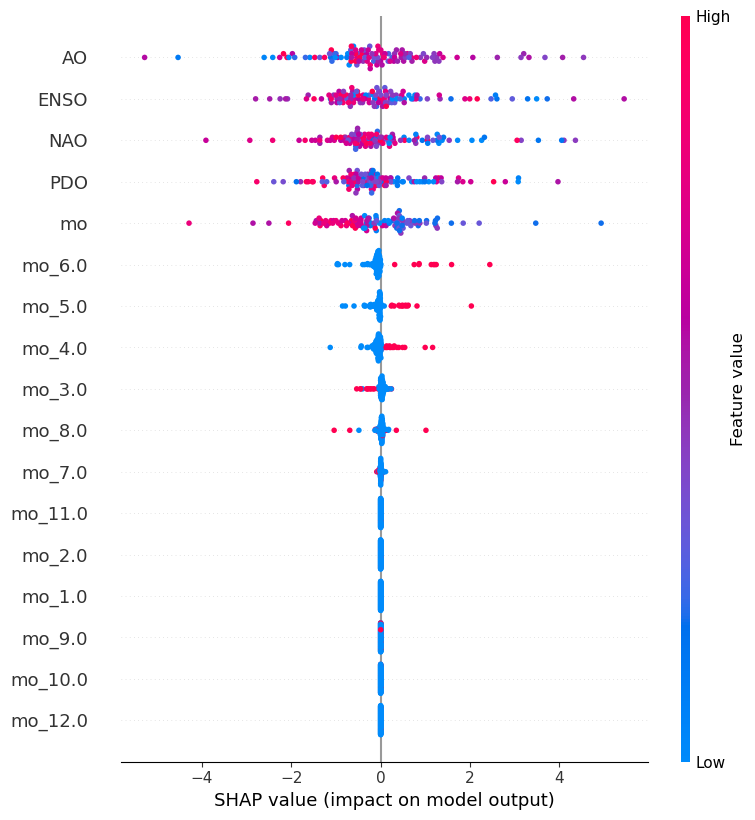

In [33]:
shap.summary_plot(shap_values, X2_test)